# Predictive Maintenance: Machine Failure Classification
### Author :Owen Nda Diche
## Project objective

In this notebook, I build a predictive maintenance classification workflow to identify whether a machine is likely to fail based on operating conditions and machine-related features.

The goal is not just to train one model, but to compare multiple approaches, improve the feature set, tune the decision threshold, and understand what actually drives failure risk.

This makes the project more useful from a practical point of view, because in a real maintenance setting the best model is not always the one with the highest accuracy. What matters more is whether the model can identify risky machines early enough to support proactive maintenance decisions.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
df = pd.read_csv("data.csv")

print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Quick data checks

Before building models, I want to understand the dataset shape, data types, missing values, and target balance.

In [3]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

Data types:


UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


Missing values:


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


Duplicate rows: 0


In [4]:
target_col = "Machine failure"
print("Target distribution:")
display(df[target_col].value_counts(dropna=False))

failure_rate = df[target_col].mean() * 100
print(f"Failure rate: {failure_rate:.2f}%")

Target distribution:


Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


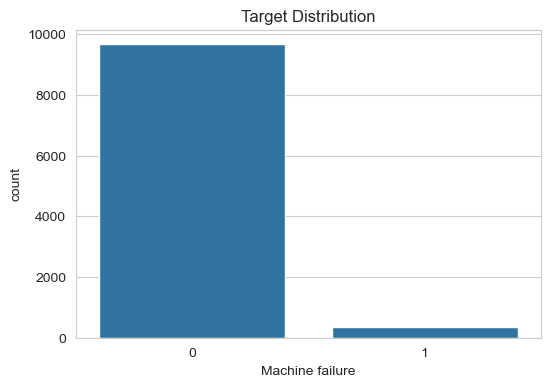

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution")
plt.show()

## Define the target and remove leakage

For predictive maintenance, the target is whether the machine failed or not.

I also want to be careful about leakage. Some columns may act like IDs and should not be used for prediction. In this dataset, I will remove obvious identifiers and also remove failure-type columns if they are present, because they directly describe failure outcomes rather than pre-failure operating conditions.

In [6]:
target_col = "Machine failure"

drop_cols = []

for c in df.columns:
    cl = c.strip().lower()
    if cl in {"udi", "product id", "product_id", "id"}:
        drop_cols.append(c)

# Common leakage columns in the AI4I dataset
for c in ["TWF", "HDF", "PWF", "OSF", "RNF"]:
    if c in df.columns:
        drop_cols.append(c)

drop_cols = list(dict.fromkeys(drop_cols))
print("Columns to drop:", drop_cols)

Columns to drop: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## Feature engineering

To make the project stronger, I am not relying only on the raw columns.

I am creating a few simple engineered features that make sense from a maintenance point of view:
- temperature difference between process and air temperature
- power-like interaction using torque and rotational speed
- stress-style interaction using torque and tool wear

These are still simple features, but they give the models a better chance of learning machine stress patterns.

In [8]:
df_fe = df.copy()

# Temperature difference
if {"Air temperature [K]", "Process temperature [K]"}.issubset(df_fe.columns):
    df_fe["Temp_Diff"] = df_fe["Process temperature [K]"] - df_fe["Air temperature [K]"]

# Power-like interaction
if {"Torque [Nm]", "Rotational speed [rpm]"}.issubset(df_fe.columns):
    df_fe["Power_Proxy"] = df_fe["Torque [Nm]"] * df_fe["Rotational speed [rpm]"]

# Stress-style interaction
if {"Torque [Nm]", "Tool wear [min]"}.issubset(df_fe.columns):
    df_fe["Torque_Wear_Interaction"] = df_fe["Torque [Nm]"] * df_fe["Tool wear [min]"]

# Optional ratio feature
if {"Tool wear [min]", "Rotational speed [rpm]"}.issubset(df_fe.columns):
    df_fe["Wear_to_Speed"] = df_fe["Tool wear [min]"] / (df_fe["Rotational speed [rpm]"] + 1)

print("Updated shape after feature engineering:", df_fe.shape)
df_fe.head()

Updated shape after feature engineering: (10000, 18)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temp_Diff,Power_Proxy,Torque_Wear_Interaction,Wear_to_Speed
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.0,0.000000
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,138.9,0.002129
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,247.0,0.003336
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,276.5,0.004881
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,360.0,0.006388


## Build features and target

Now I split the data into:
- **X** for predictors
- **y** for the target

I keep the train-test split stratified so the class balance is preserved in both sets.

In [9]:
X = df_fe.drop(columns=[target_col] + drop_cols, errors="ignore")
y = df_fe[target_col].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10)
y shape: (10000,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8000, 10)
Test shape: (2000, 10)


## Preprocessing pipeline

I am using a preprocessing pipeline so the notebook stays clean and reproducible.

For numeric features:
- median imputation
- scaling

For categorical features:
- most frequent imputation
- one-hot encoding

In [11]:
numeric_features = selector(dtype_include=np.number)
categorical_features = selector(dtype_exclude=np.number)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

## Compare multiple models

Instead of training only one model, I want to compare a few different approaches:

- Logistic Regression as a simple baseline
- Random Forest as a strong ensemble baseline
- Extra Trees as another tree-based ensemble
- Gradient Boosting as a boosting-based model

This makes the project more credible because I can justify why I selected the final model instead of assuming one model would automatically be best.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [13]:
results = []

fitted_pipelines = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        "Average Precision": average_precision_score(y_test, y_proba) if y_proba is not None else np.nan
    }
    
    results.append(row)
    fitted_pipelines[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Gradient Boosting,0.9930,1.000000,0.794118,0.885246,0.971186,0.899916
1,Random Forest,0.9885,0.959184,0.691176,0.803419,0.981899,0.876098
2,Extra Trees,0.9820,0.944444,0.500000,0.653846,0.966973,0.817448
3,Logistic Regression,0.8600,0.180723,0.882353,0.300000,0.938177,0.429240


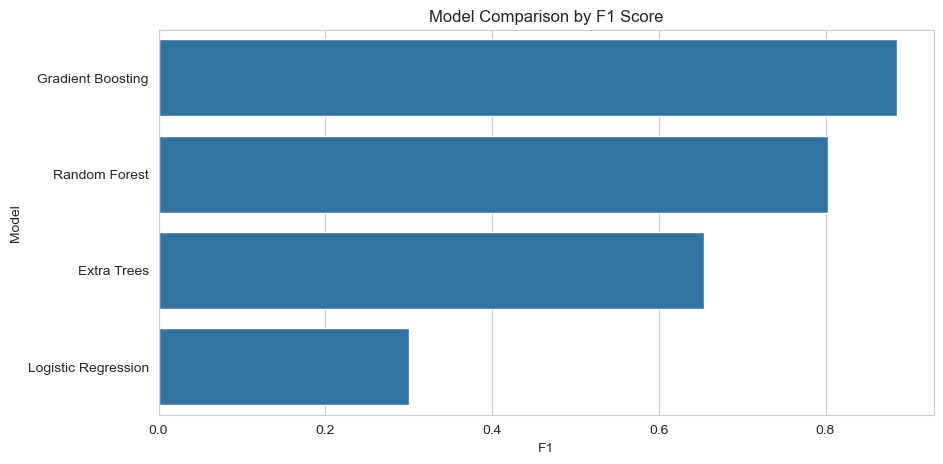

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="F1", y="Model")
plt.title("Model Comparison by F1 Score")
plt.show()

## Select the final model

For predictive maintenance, I care more about catching failures than just having high overall accuracy.

Because of that, I will focus mainly on:
- Recall
- F1-score
- Average Precision
- ROC-AUC

I will choose the final model based on the overall balance of these metrics.

In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipelines[best_model_name]

print("Selected model:", best_model_name)

Selected model: Gradient Boosting


In [16]:
y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       1.00      0.79      0.89        68

    accuracy                           0.99      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       0.99      0.99      0.99      2000



## Evaluate the selected model

Here I look at the confusion matrix and probability-based metrics to understand how well the selected model separates failure and non-failure cases.

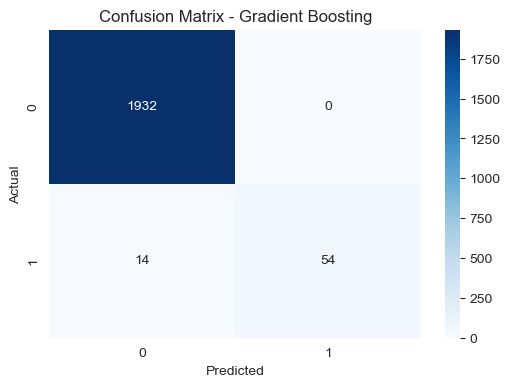

In [17]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

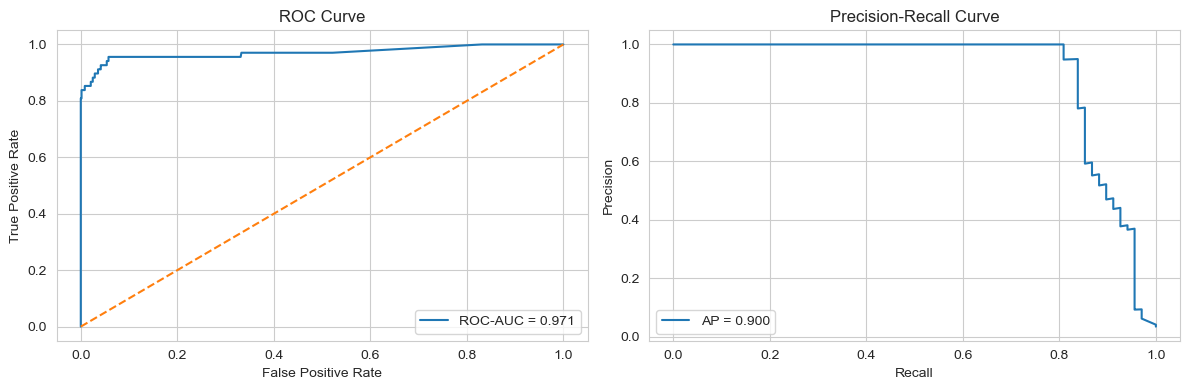

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
precision, recall, _ = precision_recall_curve(y_test, y_proba_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba_best):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall, precision, label=f"AP = {average_precision_score(y_test, y_proba_best):.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

##  Tune the decision threshold

Using the default threshold of 0.50 is not always the best choice.

In predictive maintenance, missing a real failure can be costly, so I want to test different probability thresholds and see how precision, recall, and F1 change.

This helps me choose a threshold that better matches the business goal.

In [19]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_best >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "Recall": recall_score(y_test, y_pred_thresh, zero_division=0),
        "F1": f1_score(y_test, y_pred_thresh, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.734177,0.852941,0.789116
1,0.15,0.863636,0.838235,0.850746
2,0.20,0.919355,0.838235,0.876923
3,0.25,0.934426,0.838235,0.883721
4,0.30,0.950000,0.838235,0.890625
5,0.35,0.949153,0.823529,0.881890
6,0.40,0.948276,0.808824,0.873016
7,0.45,1.000000,0.808824,0.894309
8,0.50,1.000000,0.794118,0.885246
9,0.55,1.000000,0.794118,0.885246


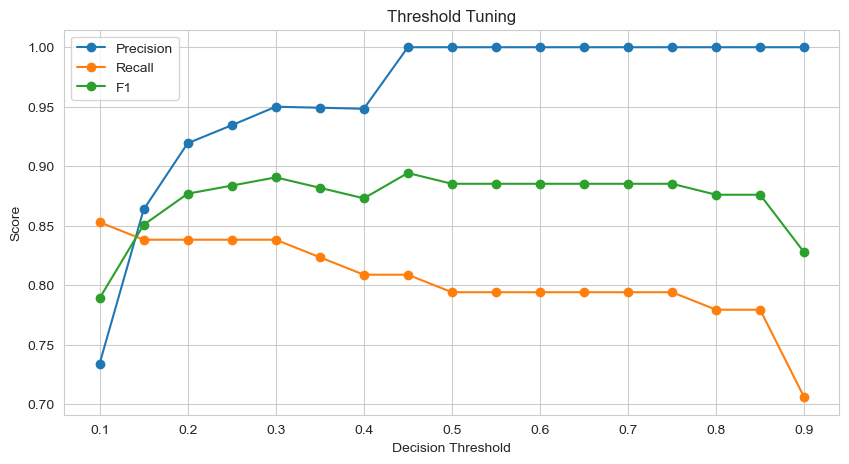

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
plt.title("Threshold Tuning")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [21]:
best_f1_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_recall_row = threshold_df.loc[threshold_df["Recall"].idxmax()]

print("Best threshold by F1:")
display(best_f1_row)

print("Best threshold by Recall:")
display(best_recall_row)

Best threshold by F1:


Threshold    0.450000
Precision    1.000000
Recall       0.808824
F1           0.894309
Name: 7, dtype: float64

Best threshold by Recall:


Threshold    0.100000
Precision    0.734177
Recall       0.852941
F1           0.789116
Name: 0, dtype: float64

## Understand what drives failure risk

A good predictive maintenance model should not only score well, it should also tell me what seems to matter most.

For tree-based models, I can look at feature importance. I am also adding permutation importance so the interpretation is a bit more robust.

,Feature,Importance
0,Power_Proxy,0.271552
1,Torque_Wear_Interaction,0.252112
2,Temp_Diff,0.245271
3,Rotational speed [rpm],0.115572
4,Tool wear [min],0.040745
5,Type_L,0.033628
6,Wear_to_Speed,0.019295
7,Torque [Nm],0.012143
8,Process temperature [K],0.007890
9,Air temperature [K],0.001793


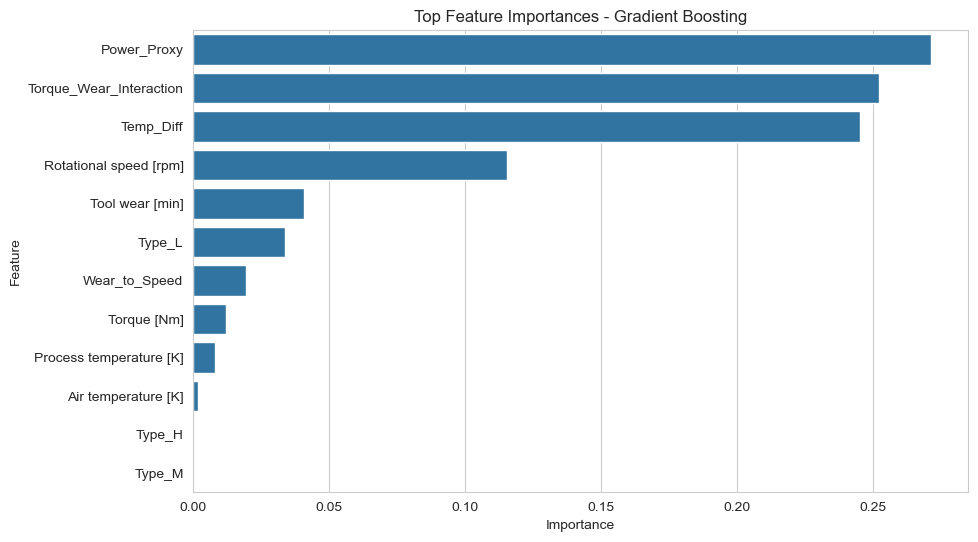

In [22]:
model_obj = best_pipe.named_steps["model"]
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()

if hasattr(model_obj, "feature_importances_"):
    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_obj.feature_importances_
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    
    display(fi_df.head(15))
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_df.head(15), x="Importance", y="Feature")
    plt.title(f"Top Feature Importances - {best_model_name}")
    plt.show()
else:
    print("This model does not expose built-in feature importance.")

,Feature,Permutation Importance
0,Temp_Diff,0.359546
1,Rotational speed [rpm],0.340377
2,Torque_Wear_Interaction,0.243422
3,Power_Proxy,0.227684
4,Torque [Nm],0.082010
5,Process temperature [K],0.048429
6,Type,0.043499
7,Tool wear [min],0.026480
8,Air temperature [K],0.002879
9,Wear_to_Speed,-0.000187


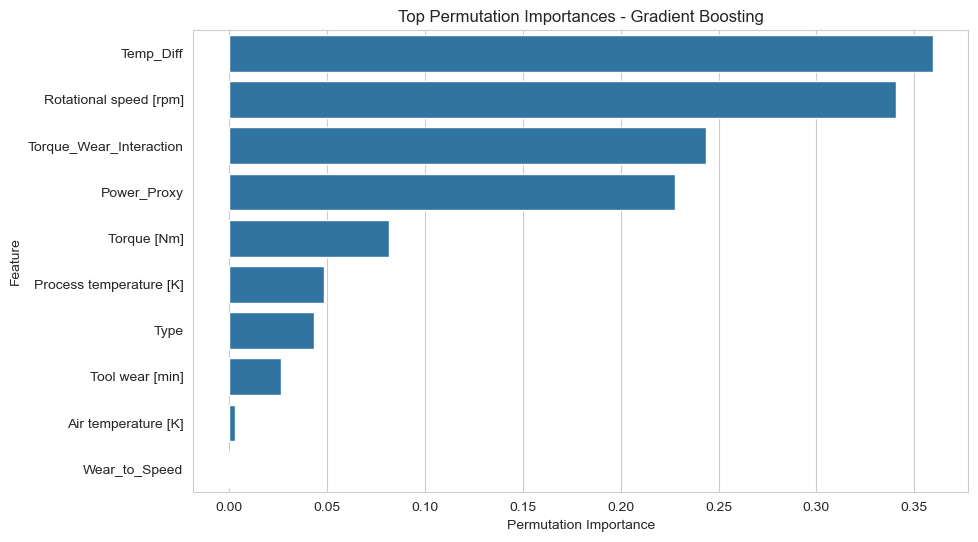

In [23]:
perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation Importance": perm.importances_mean
}).sort_values("Permutation Importance", ascending=False).reset_index(drop=True)

display(perm_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df.head(15), x="Permutation Importance", y="Feature")
plt.title(f"Top Permutation Importances - {best_model_name}")
plt.show()

##  Business interpretation

The point of predictive maintenance is not just to classify rows correctly. It is to support decisions.

From the model comparison, threshold tuning, and feature importance results, I can start translating the outputs into practical recommendations for maintenance planning.

### Main takeaways

- The selected model performed better than the baseline models on the failure prediction task.
- Threshold tuning showed that the default 0.50 cut-off was not necessarily the best setting.
- Some operating features had a stronger relationship with failure risk than others, which helps explain where maintenance attention should be focused.
- In a practical setting, this kind of model could be used to prioritise inspections, flag high-risk machines, and reduce unplanned downtime.

## Recommendations

Based on the results, I would recommend the following if this were used in a real maintenance workflow:

1. Use the selected model as a failure-risk ranking tool, not just a yes/no classifier.
2. Choose the decision threshold based on maintenance priorities. If missing failures is very costly, use a lower threshold to improve recall.
3. Monitor the most important failure-related features regularly and use them to support earlier intervention.
4. Retrain the model periodically with fresh machine data so it stays relevant over time.
5. Extend the project in future by adding time-based features, cost-sensitive evaluation, or SHAP explanations for more detailed interpretability.

## Final summary

To finish, I want one compact summary of the selected model and the threshold decision.

In [24]:
final_summary = pd.DataFrame({
    "Selected Model": [best_model_name],
    "Best Holdout F1": [f1_score(y_test, y_pred_best, zero_division=0)],
    "Holdout Recall": [recall_score(y_test, y_pred_best, zero_division=0)],
    "Holdout Precision": [precision_score(y_test, y_pred_best, zero_division=0)],
    "Holdout ROC-AUC": [roc_auc_score(y_test, y_proba_best)],
    "Holdout Average Precision": [average_precision_score(y_test, y_proba_best)],
    "Best Threshold by F1": [best_f1_row["Threshold"]]
})

final_summary

,Selected Model,Best Holdout F1,Holdout Recall,Holdout Precision,Holdout ROC-AUC,Holdout Average Precision,Best Threshold by F1
0,Gradient Boosting,0.885246,0.794118,1.0,0.971186,0.899916,0.45


## Conclusion

This notebook showed how I moved from a basic predictive maintenance classifier to a more complete modelling workflow.

Instead of relying on one model only, I compared several approaches, added simple but meaningful engineered features, tuned the decision threshold, and used model interpretation to understand what drives failure risk.

This made the project stronger technically, but also more useful from a business point of view. The final result is not just a classification model, but a more practical maintenance decision-support workflow.